In [1]:
import boto3
import botocore
from iterdub import iterdub as ib
import matplotlib.pyplot as plt
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervma94yk
interpreter: 3.10.12 (main, Aug 31 2026, 10:18:17) [GCC 11.4.0]
notebook name: bucket=prq49--a=all_stints_all_series_profiles+endeavor=16--fitness
notebook path: /home/runner/work/oee4/oee4/binder/bucket=prq49--a=all_stints_all_series_profiles+endeavor=16--fitness.ipynb
revision: bdac574
timestamp: 2026-09-29T12:28:06Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


# get data


In [4]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


In [5]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-5-747b1fe91af5>:1: DtypeWarning: Columns (286,293,300,301,302,303,305,306,307,308,314,315,316,317,318,324,325,326) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-333308f100cbd3f8'

In [6]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [7]:
dfm10 = df[ df['Stint'] % 10 == 0 ]


# how does fitness change over time?


<ipython-input-8-e15cb135e74e>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=countplot+x=stint+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=countplot+x=stint+ext=.png


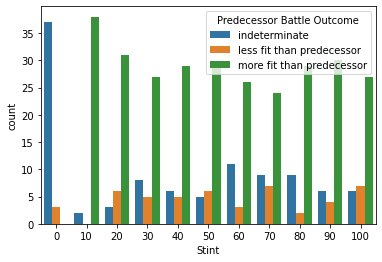

<AxesSubplot:xlabel='Stint', ylabel='count'>

In [8]:
tp.tee(
    sns.countplot,
    data=dfm10,
    x='Stint',
    hue='Predecessor Battle Outcome',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'filter-Stint-mod10',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-9-650f81416c5e>:25: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=hline-boxplot+x=stint+y=fitness-complexity-delta+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=hline-boxplot+x=stint+y=fitness-complexity-delta+ext=.png


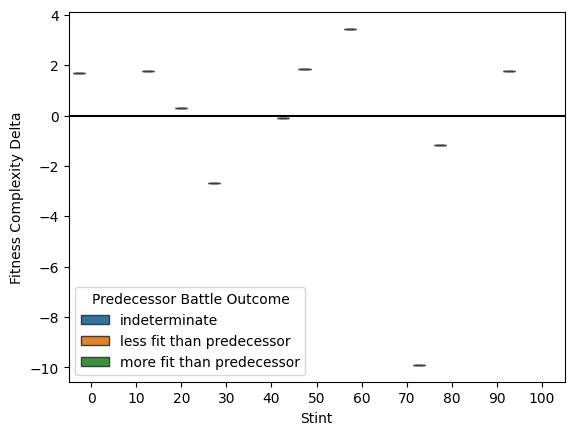

In [9]:
def hline_boxplot(*args, **kwargs):
    plt.axhline(
        0,
        c='k',
        zorder=-1,
    )
    sns.boxplot(
        *args,
        **kwargs,
    )

tp.tee(
    hline_boxplot,
    data=dfm10,
    x='Stint',
    y='Fitness Complexity Delta',
    hue='Predecessor Battle Outcome',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'filter-Stint-mod10',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-10-347e9419a1f3>:14: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=barplot+x=stint+y=fitness-complexity+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=predecessor-battle-outcome+transform=filter-Stint-mod10+viz=barplot+x=stint+y=fitness-complexity+ext=.png


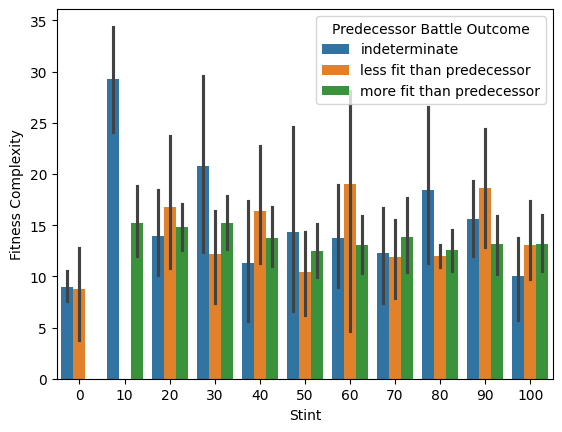

<AxesSubplot:xlabel='Stint', ylabel='Fitness Complexity'>

In [10]:
tp.tee(
    sns.barplot,
    data=dfm10,
    x='Stint',
    y='Fitness Complexity',
    hue='Predecessor Battle Outcome',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'filter-Stint-mod10',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)
